<a href="https://colab.research.google.com/github/firstsignal/activation-geometry-sentiment/blob/main/ch4_scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install transformer-lens


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.7 MB/s eta 0:00:00


In [2]:
import torch
from transformer_lens import HookedTransformer

sentence = "The meal at the restaurant was absolutely"
words = [" wonderful", " terrible", " delicious", " awful", " perfect", " horrible"]

for name in ["pythia-70m", "pythia-160m", "pythia-410m"]:
    model = HookedTransformer.from_pretrained(name)
    logits = model(model.to_tokens(sentence))[0, -1]
    probs = logits.softmax(-1)
    print(f"\n===== {name} =====")
    top = probs.topk(10)
    print("top 10:", [model.tokenizer.decode([i]) for i in top.indices])
    for w in words:
        tid = model.to_tokens(w, prepend_bos=False)[0, 0]
        rank = (probs > probs[tid]).sum().item() + 1
        print(f"{w!r:>12}: rank {rank}")
    del model; torch.cuda.empty_cache() if torch.cuda.is_available() else None


config.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/166M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Loaded pretrained model pythia-410m into HookedTransformer

===== pythia-410m =====
top 10: [' delicious', ' fantastic', ' amazing', ' wonderful', ' fabulous', ' incredible', ' divine', ' superb', ' excellent', ' perfect']
' wonderful': rank 4
 ' terrible': rank 39
' delicious': rank 1
    ' awful': rank 50
  ' perfect': rank 10
 ' horrible': rank 56


Prediction, locked: the concentration ceiling is scale-invariant — the soak’s share on the sentiment axis saturates at roughly the same ~40% in Pythia-160m and Pythia-410m as in 70m, despite the growing dimensionality of the space.

In [3]:
import torch
from transformer_lens import HookedTransformer

pos_matched = [
    "The meal at the restaurant was absolutely wonderful.",
    "Her performance in the final act was brilliant.",
    "The weather on the coast stayed lovely all week.",
    "His speech at the ceremony sounded inspiring.",
    "The ending of the novel felt satisfying.",
]
neg_matched = [
    "The meal at the restaurant was absolutely terrible.",
    "Her performance in the final act was dreadful.",
    "The weather on the coast stayed miserable all week.",
    "His speech at the ceremony sounded tedious.",
    "The ending of the novel felt hollow.",
]
test_pairs = [
    ("The concert in the park sounded wonderful and the crowd stayed late.",
     "The concert in the park sounded terrible and the crowd stayed late."),
    ("Her garden looked beautiful after the rain stopped falling.",
     "Her garden looked dreadful after the rain stopped falling."),
    ("The service at the hotel was excellent and the staff seemed calm.",
     "The service at the hotel was awful and the staff seemed calm."),
    ("His first attempt at the recipe tasted delicious and the kitchen smelled good.",
     "His first attempt at the recipe tasted disgusting and the kitchen smelled good."),
    ("The view from the window seemed lovely in the morning light.",
     "The view from the window seemed miserable in the morning light."),
    ("The lecture on physics felt inspiring and the students asked questions.",
     "The lecture on physics felt tedious and the students asked questions."),
    ("The journey through the mountains was pleasant and the roads stayed clear.",
     "The journey through the mountains was horrible and the roads stayed clear."),
    ("The film about the ocean looked stunning and the music matched well.",
     "The film about the ocean looked boring and the music matched well."),
    ("The bread from the bakery smelled amazing and the queue moved quickly.",
     "The bread from the bakery smelled horrid and the queue moved quickly."),
    ("The report on the findings read brilliant and the figures looked clean.",
     "The report on the findings read hopeless and the figures looked clean."),
]

def flip_and_window(tp, tn):
    if tp.shape != tn.shape: return None, None
    d = (tp[0] != tn[0]).nonzero().flatten()
    if len(d) != 1: return None, None
    f = d.item()
    return f, (f + 1, tp.shape[1])

all_results = {}   # model_name -> (n_layers, d_model, per-layer mean/min/max ratio, rand)

for name in ["pythia-70m", "pythia-160m", "pythia-410m"]:
    model = HookedTransformer.from_pretrained(name)
    n_layers, d_model = model.cfg.n_layers, model.cfg.d_model
    print(f"\n===== {name}  ({n_layers} layers, d_model={d_model}) =====")

    def resid_at(prompts, layer):
        vecs = []
        for p in prompts:
            _, c = model.run_with_cache(model.to_tokens(p))
            vecs.append(c["resid_post", layer][0].mean(dim=0))
        return torch.stack(vecs)

    axes = {}
    for L in range(n_layers):
        pa, na = resid_at(pos_matched, L), resid_at(neg_matched, L)
        a = pa.mean(0) - na.mean(0); axes[L] = a / a.norm()

    torch.manual_seed(3)
    rand_axis = torch.randn(d_model); rand_axis = rand_axis / rand_axis.norm()

    ratios = {L: [] for L in range(n_layers)}
    rands  = {L: [] for L in range(n_layers)}
    used = 0
    for s_pos, s_neg in test_pairs:
        tpk, tnk = model.to_tokens(s_pos), model.to_tokens(s_neg)
        f, win = flip_and_window(tpk, tnk)
        if f is None: continue
        used += 1
        _, cpp = model.run_with_cache(tpk); _, cnn = model.run_with_cache(tnk)
        for L in range(n_layers):
            dvec = cpp["resid_post", L][0] - cnn["resid_post", L][0]
            ax = axes[L]
            on  = (dvec @ ax).abs()[win[0]:win[1]].mean().item()
            off = (dvec - (dvec @ ax)[:, None] * ax[None, :]).norm(dim=-1)[win[0]:win[1]].mean().item()
            rnd = (dvec @ rand_axis).abs()[win[0]:win[1]].mean().item()
            ratios[L].append(on / off); rands[L].append(rnd / off)

    print(f"pairs used: {used}/10")
    print(f"{'layer':>5} {'depth%':>7} {'ratio':>7} {'min':>6} {'max':>6} {'rand':>6}")
    summary = []
    for L in range(n_layers):
        r = torch.tensor(ratios[L]); rr = torch.tensor(rands[L])
        print(f"{L:>5} {100*L/(n_layers-1):>6.0f}% {r.mean():>7.3f} {r.min():>6.3f} {r.max():>6.3f} {rr.mean():>6.3f}")
        summary.append((L/(n_layers-1), r.mean().item(), r.min().item(), r.max().item(), rr.mean().item()))
    all_results[name] = (n_layers, d_model, summary)

    peak = max(s[1] for s in summary)
    print(f"--> concentration ceiling for {name}: {peak:.3f}")

    del model
    import gc; gc.collect()


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loaded pretrained model pythia-70m into HookedTransformer

===== pythia-70m  (6 layers, d_model=512) =====
pairs used: 9/10
layer  depth%   ratio    min    max   rand
    0      0%   0.130  0.043  0.261  0.041
    1     20%   0.242  0.158  0.349  0.036
    2     40%   0.241  0.094  0.362  0.032
    3     60%   0.341  0.222  0.490  0.032
    4     80%   0.402  0.178  0.491  0.027
    5    100%   0.379  0.140  0.484  0.038
--> concentration ceiling for pythia-70m: 0.402


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model pythia-160m into HookedTransformer

===== pythia-160m  (12 layers, d_model=768) =====
pairs used: 9/10
layer  depth%   ratio    min    max   rand
    0      0%   0.141  0.049  0.231  0.030
    1      9%   0.097  0.059  0.165  0.027
    2     18%   0.139  0.089  0.201  0.028
    3     27%   0.224  0.129  0.340  0.030
    4     36%   0.321  0.180  0.432  0.026
    5     45%   0.309  0.122  0.445  0.031
    6     55%   0.303  0.199  0.424  0.021
    7     64%   0.357  0.148  0.493  0.021
    8     73%   0.301  0.158  0.384  0.025
    9     82%   0.303  0.127  0.416  0.024
   10     91%   0.253  0.107  0.366  0.026
   11    100%   0.244  0.104  0.364  0.027
--> concentration ceiling for pythia-160m: 0.357


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Loaded pretrained model pythia-410m into HookedTransformer

===== pythia-410m  (24 layers, d_model=1024) =====
pairs used: 9/10
layer  depth%   ratio    min    max   rand
    0      0%   0.139  0.019  0.248  0.019
    1      4%   0.098  0.048  0.148  0.027
    2      9%   0.065  0.038  0.112  0.027
    3     13%   0.141  0.084  0.209  0.020
    4     17%   0.116  0.060  0.187  0.022
    5     22%   0.351  0.235  0.559  0.023
    6     26%   0.312  0.204  0.533  0.022
    7     30%   0.328  0.192  0.450  0.029
    8     35%   0.302  0.169  0.455  0.022
    9     39%   0.275  0.162  0.414  0.023
   10     43%   0.383  0.273  0.535  0.028
   11     48%   0.362  0.236  0.516  0.026
   12     52%   0.404  0.302  0.586  0.024
   13     57%   0.585  0.363  0.852  0.017
   14     61%   0.434  0.223  0.648  0.021
   15     65%   0.471  0.276  0.685  0.020
   16     70%   0.464  0.260  0.633  0.019
   17     74%   0.486  0.308  0.655  0.021
   18     78%   0.481  0.300  0.650  0.021
   19     83

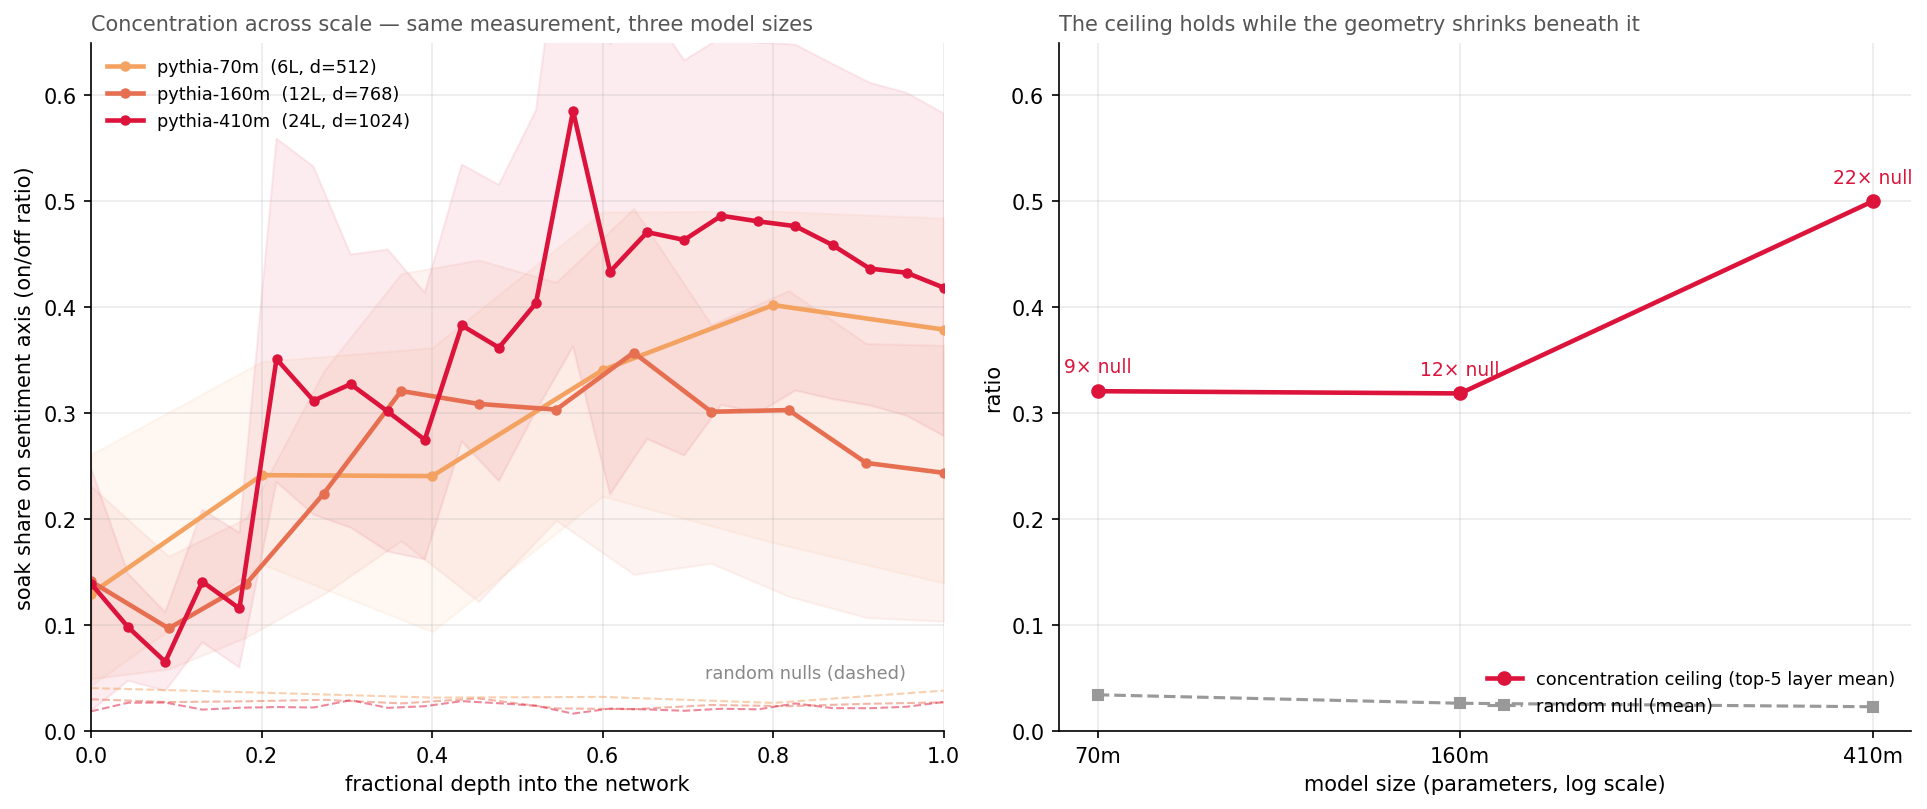

In [6]:
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), dpi=150)
fig.patch.set_facecolor('white')

colors = {"pythia-70m": "#f4a261", "pythia-160m": "#e76f51", "pythia-410m": "#dc143c"}

# ---- Panel 1: the three curves on fractional depth ----
for name, (n_layers, d_model, summary) in all_results.items():
    depth = np.array([s[0] for s in summary])
    mean  = np.array([s[1] for s in summary])
    lo    = np.array([s[2] for s in summary])
    hi    = np.array([s[3] for s in summary])
    rand  = np.array([s[4] for s in summary])
    c = colors[name]
    ax1.fill_between(depth, lo, hi, color=c, alpha=0.08)
    ax1.plot(depth, mean, 'o-', color=c, lw=2.2, ms=4,
             label=f"{name}  ({n_layers}L, d={d_model})")
    ax1.plot(depth, rand, '--', color=c, lw=1, alpha=0.5)

ax1.text(0.72, 0.05, "random nulls (dashed)", fontsize=8.5, color='#888888')
ax1.set_xlabel("fractional depth into the network", fontsize=10)
ax1.set_ylabel("soak share on sentiment axis (on/off ratio)", fontsize=10)
ax1.set_title("Concentration across scale — same measurement, three model sizes",
              fontsize=10, loc='left', color='#555555')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 0.65)
ax1.legend(fontsize=8.5, loc='upper left', frameon=False)
ax1.spines[['top','right']].set_visible(False)
ax1.grid(alpha=0.25)

# ---- Panel 2: ceiling vs null — the scale trend ----
names   = list(all_results.keys())
params  = [70, 160, 410]

# robust ceiling: mean of each model's top-5 layers (spike-proof)
ceils   = [np.mean(sorted([s[1] for s in all_results[n][2]], reverse=True)[:5]) for n in names]
nulls   = [np.mean([s[4] for s in all_results[n][2]]) for n in names]
times   = [c/nl for c, nl in zip(ceils, nulls)]

ax2.plot(params, ceils, 'o-', color='#dc143c', lw=2.2, ms=6, label='concentration ceiling (top-5 layer mean)')
ax2.plot(params, nulls, 's--', color='#999999', lw=1.5, ms=5, label='random null (mean)')
for p, c, t in zip(params, ceils, times):
    ax2.annotate(f"{t:.0f}× null", (p, c), textcoords="offset points",
                 xytext=(0, 9), ha='center', fontsize=9, color='#dc143c')
ax2.set_xscale('log')
ax2.set_xticks(params); ax2.set_xticklabels(['70m', '160m', '410m'])
ax2.xaxis.set_minor_locator(plt.NullLocator())
ax2.set_xlabel("model size (parameters, log scale)", fontsize=10)
ax2.set_ylabel("ratio", fontsize=10)
ax2.set_title("The ceiling holds while the geometry shrinks beneath it",
              fontsize=10, loc='left', color='#555555')
ax2.set_ylim(0, 0.65)
ax2.legend(fontsize=8.5, loc='lower right', frameon=False)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.savefig("concentration_across_scale.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
